# Advanced DQN Multi-Asset Trading Agent (Phase 3)

This notebook implements the **Advanced Architecture** for the DQN agent, including:
1.  **Reward Clipping**: `[-1, 1]` to stabilize training.
2.  **Temporal Memory (LSTM)**: Using a 10-day window of past states.
3.  **Dueling LSTM Architecture**: Separating Value and Advantage streams.

## 1. Imports & Setup

In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import yfinance as yf
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

## 2. Data Preparation

Downloading data for `SPY`, `QQQ`, `TLT`, `GLD` and calculating Log Returns and Volatility.

In [3]:
def get_autonomous_data():
    tickers = ['SPY', 'QQQ', 'TLT', 'GLD']
    start_date = "2010-01-01"
    end_date = "2025-01-01"
    
    print(f"Downloading data for {tickers}...")
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)
    
    # Use 'Close' prices for calculations
    df_close = data['Close']
    
    # Handle missing values
    df_close = df_close.ffill().dropna()
    
    # Calculate Log Returns
    df_log_ret = np.log(df_close / df_close.shift(1))
    
    # Calculate Rolling Volatility (20-day standard deviation of log returns)
    df_vol = df_log_ret.rolling(window=20).std()
    
    # Combine features
    features = pd.concat([df_log_ret, df_vol], axis=1)
    features.columns = [f'{col}_ret' for col in df_log_ret.columns] + [f'{col}_vol' for col in df_vol.columns]
    
    # Drop NaN from rolling window
    features = features.dropna()
    
    # Also keep raw prices for portfolio value calculation
    prices = df_close.loc[features.index]
    
    print(f"Data shape: {features.shape}")
    return prices, features

prices, features = get_autonomous_data()
features.head()

[*********************100%***********************]  4 of 4 completed

Data shape: (3754, 8)


,GLD_ret,QQQ_ret,SPY_ret,TLT_ret,GLD_vol,QQQ_vol,SPY_vol,TLT_vol
Date,,,,,,,,
2010-02-02,0.007173,0.008975,0.012031,0.002848,0.011791,0.012731,0.010619,0.008259
2010-02-03,-0.003948,0.005483,-0.004995,-0.011664,0.011819,0.012859,0.010606,0.008603
2010-02-04,-0.040649,-0.029363,-0.031352,0.015703,0.014186,0.014160,0.012480,0.008675
2010-02-05,0.002966,0.008411,0.002065,0.002177,0.014236,0.014398,0.012421,0.008677
2010-02-08,-0.006133,-0.007239,-0.007245,0.001304,0.014132,0.014145,0.012344,0.008665


## 3. Advanced Portfolio Environment

- **Window Size**: 10 days (LSTM input).
- **Reward Clipping**: `np.clip(reward, -1, 1)`.

In [4]:
class PortfolioEnv(gym.Env):
    def __init__(self, prices, features, initial_balance=10000, window_size=10):
        super(PortfolioEnv, self).__init__()
        
        self.prices = prices
        self.features = features
        self.initial_balance = initial_balance
        self.window_size = window_size
        self.assets = prices.columns.tolist()
        self.n_assets = len(self.assets)
        
        # Action Space: 0=Hold, 1-4=Buy 10%, 5-8=Sell 10%
        self.action_space = spaces.Discrete(1 + 2 * self.n_assets)
        
        # Observation Space: (Window_Size, Features)
        self.input_dims = (2 * self.n_assets) + (1 + self.n_assets) + self.n_assets + 2
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window_size, self.input_dims), dtype=np.float32)
        
        self.state_memory = deque(maxlen=self.window_size)
        
        self.current_step = 0
        self.max_steps = len(features) - 1
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        self.current_step = 0
        self.balance = self.initial_balance
        self.holdings = np.zeros(self.n_assets)
        self.avg_buy_price = np.zeros(self.n_assets)
        self.portfolio_value = self.initial_balance
        self.portfolio_history = [self.initial_balance]
        self.weight_history = []
        
        # Domain Randomization
        self.risk_aversion = np.random.uniform(0, 1)
        self.time_horizon = np.random.uniform(0, 1)
        
        self.state_memory.clear()
        initial_state = self._get_single_day_features()
        for _ in range(self.window_size):
            self.state_memory.append(initial_state)
            
        return np.array(self.state_memory), {}
    
    def _get_single_day_features(self):
        market_data = self.features.iloc[self.current_step].values
        current_prices = self.prices.iloc[self.current_step].values
        asset_values = self.holdings * current_prices
        total_value = self.balance + np.sum(asset_values)
        
        weights = np.concatenate(([self.balance], asset_values)) / total_value
        
        price_ratios = np.zeros(self.n_assets)
        for i in range(self.n_assets):
            if self.avg_buy_price[i] > 0:
                price_ratios[i] = current_prices[i] / self.avg_buy_price[i]
            else:
                price_ratios[i] = 1.0
                
        context = np.array([self.risk_aversion, self.time_horizon])
        
        state = np.concatenate((market_data, weights, price_ratios, context))
        return state.astype(np.float32)
    
    def step(self, action):
        current_prices = self.prices.iloc[self.current_step].values
        
        # Execute Action
        if action > 0:
            asset_idx = (action - 1) % self.n_assets
            is_buy = (action - 1) < self.n_assets
            
            if is_buy:
                total_value = self.balance + np.sum(self.holdings * current_prices)
                trade_amount = 0.1 * total_value
                if self.balance >= trade_amount:
                    shares = trade_amount / current_prices[asset_idx]
                    total_cost = (self.holdings[asset_idx] * self.avg_buy_price[asset_idx]) + trade_amount
                    self.holdings[asset_idx] += shares
                    self.avg_buy_price[asset_idx] = total_cost / self.holdings[asset_idx]
                    self.balance -= trade_amount
            else:
                if self.holdings[asset_idx] > 0:
                    shares_to_sell = 0.1 * self.holdings[asset_idx]
                    self.holdings[asset_idx] -= shares_to_sell
                    self.balance += shares_to_sell * current_prices[asset_idx]
                    if self.holdings[asset_idx] < 1e-6:
                        self.holdings[asset_idx] = 0
                        self.avg_buy_price[asset_idx] = 0
        
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        truncated = False
        
        new_prices = self.prices.iloc[self.current_step].values
        new_total_value = self.balance + np.sum(self.holdings * new_prices)
        
        prev_total_value = self.portfolio_history[-1]
        daily_ret = (new_total_value - prev_total_value) / prev_total_value
        
        current_vols = self.features.iloc[self.current_step][[c for c in self.features.columns if '_vol' in c]].values
        asset_weights = (self.holdings * new_prices) / new_total_value
        portfolio_vol_proxy = np.sum(asset_weights * current_vols)
        
        raw_reward = (daily_ret - (self.risk_aversion * portfolio_vol_proxy * 0.1)) * 20
        reward = np.clip(raw_reward, -1, 1) # CLIPPING
        
        self.portfolio_history.append(new_total_value)
        self.weight_history.append(np.concatenate(([self.balance], self.holdings * new_prices)) / new_total_value)
        
        next_state_features = self._get_single_day_features()
        self.state_memory.append(next_state_features)
        
        return np.array(self.state_memory), reward, terminated, truncated, {}
        
    def render(self):
        pass

## 4. Dueling LSTM DQN Agent

Architecture:
1.  **LSTM Layer**: Processes sequence of 10 days.
2.  **Dueling Heads**: Value (V) and Advantage (A).

In [5]:
class DuelingLSTMDQN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=64, num_layers=2):
        super(DuelingLSTMDQN, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True
        )
        
        self.value_stream = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_step = lstm_out[:, -1, :]
        
        values = self.value_stream(last_step)
        advantages = self.advantage_stream(last_step)
        
        q_values = values + (advantages - advantages.mean(dim=1, keepdim=True))
        return q_values

class DQNAgent:
    def __init__(self, input_dim, output_dim, lr=1e-3, gamma=0.99, epsilon_start=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.policy_net = DuelingLSTMDQN(input_dim, output_dim).to(self.device)
        self.target_net = DuelingLSTMDQN(input_dim, output_dim).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
        self.memory = deque(maxlen=10000)
        self.batch_size = 64
        
    def act(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.output_dim)
        
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.policy_net(state)
        return q_values.argmax().item()
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
        
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)
        
        current_q = self.policy_net(states).gather(1, actions)
        
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1)[0].unsqueeze(1)
            target_q = rewards + (self.gamma * next_q * (1 - dones))
            
        loss = self.loss_fn(current_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

## 5. Training Loop

In [5]:
env = PortfolioEnv(prices, features, window_size=10)
agent = DQNAgent(env.input_dims, env.action_space.n, lr=1e-4, epsilon_decay=0.9995)

episodes = 500
rewards_history = []

print("Starting Training (Phase 3)...")
for e in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        
        agent.replay()
        
    if e % 10 == 0:
        agent.update_target_network()
        print(f"Episode {e}/{episodes}, Total Reward: {total_reward:.2f}, Epsilon: {agent.epsilon:.2f}")
    
    rewards_history.append(total_reward)

print("Training Complete.")

Starting Training (Phase 3)...
Episode 0/500, Total Reward: 10.13, Epsilon: 0.16
Episode 10/500, Total Reward: 7.43, Epsilon: 0.01
Episode 20/500, Total Reward: 27.06, Epsilon: 0.01
Episode 30/500, Total Reward: -19.92, Epsilon: 0.01
Episode 40/500, Total Reward: 29.28, Epsilon: 0.01
Episode 50/500, Total Reward: -23.02, Epsilon: 0.01
Episode 60/500, Total Reward: -4.87, Epsilon: 0.01
Episode 70/500, Total Reward: 15.77, Epsilon: 0.01
Episode 80/500, Total Reward: -33.72, Epsilon: 0.01
Episode 90/500, Total Reward: -22.85, Epsilon: 0.01
Episode 100/500, Total Reward: 17.08, Epsilon: 0.01
Episode 110/500, Total Reward: -36.73, Epsilon: 0.01
Episode 120/500, Total Reward: -14.88, Epsilon: 0.01
Episode 130/500, Total Reward: -7.35, Epsilon: 0.01
Episode 140/500, Total Reward: -5.12, Epsilon: 0.01
Episode 150/500, Total Reward: -35.76, Epsilon: 0.01
Episode 160/500, Total Reward: -36.13, Epsilon: 0.01
Episode 170/500, Total Reward: -31.60, Epsilon: 0.01
Episode 180/500, Total Reward: 30.43

## 6. Visualization & Analysis

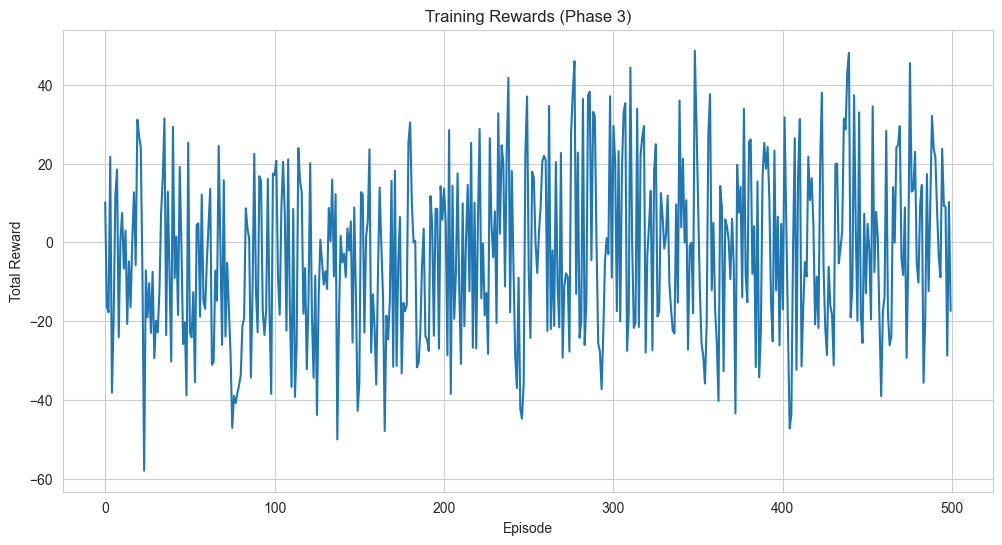

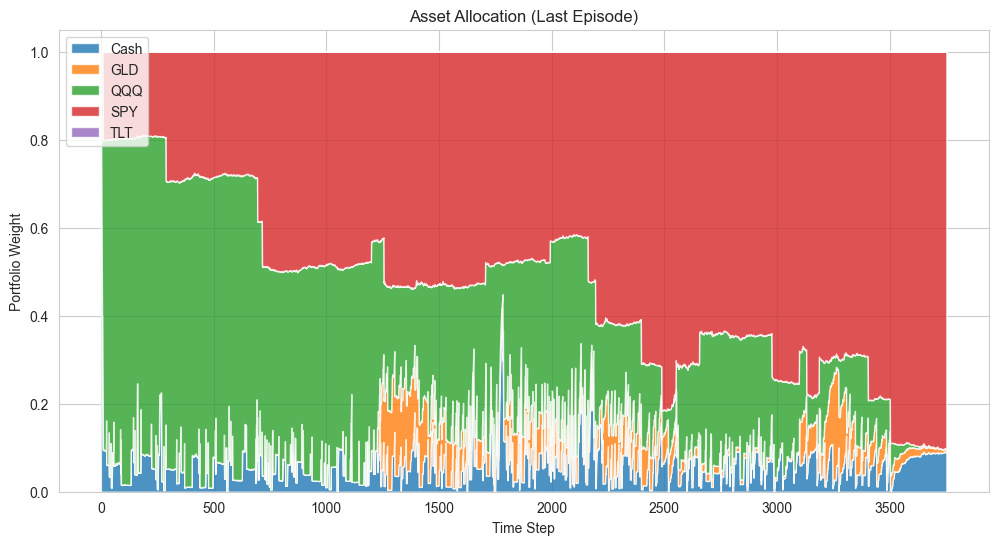

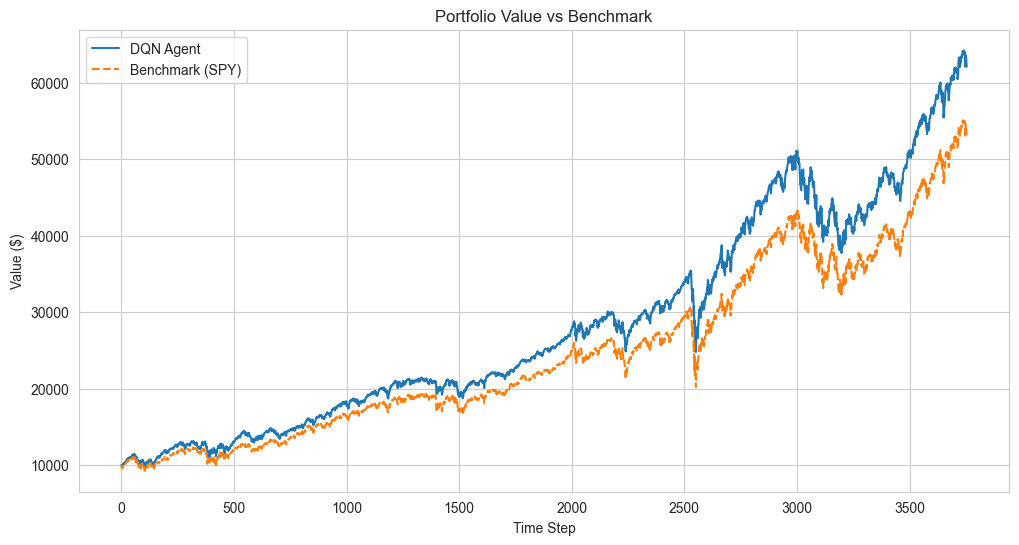

In [6]:
# Visualization

# 1. Training Rewards
plt.figure(figsize=(12, 6))
plt.plot(rewards_history)
plt.title("Training Rewards (Phase 3)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

# 2. Asset Allocation (Last Episode)
weights = np.array(env.weight_history)
labels = ['Cash'] + env.assets

plt.figure(figsize=(12, 6))
plt.stackplot(range(len(weights)), weights.T, labels=labels, alpha=0.8)
plt.title("Asset Allocation (Last Episode)")
plt.xlabel("Time Step")
plt.ylabel("Portfolio Weight")
plt.legend(loc='upper left')
plt.show()

# 3. Portfolio Value vs Benchmark (Buy & Hold SPY)
# Calculate Benchmark
spy_prices = env.prices['SPY'].values
benchmark_value = (spy_prices / spy_prices[0]) * env.initial_balance

plt.figure(figsize=(12, 6))
plt.plot(env.portfolio_history, label='DQN Agent')
plt.plot(benchmark_value[:len(env.portfolio_history)], label='Benchmark (SPY)', linestyle='--')
plt.title("Portfolio Value vs Benchmark")
plt.xlabel("Time Step")
plt.ylabel("Value ($)")
plt.legend()
plt.show()

--- 1. Dividiendo datos ---
Total Días: 3754
Entrenamiento: 3003 días
Test (Examen): 751 días

--- 2. Entrenando Agente en conjunto restringido ---
Train Episode 0/50 - Reward: 11.28 - Epsilon: 0.23
Train Episode 10/50 - Reward: 15.97 - Epsilon: 0.01
Train Episode 20/50 - Reward: 8.46 - Epsilon: 0.01
Train Episode 30/50 - Reward: -29.87 - Epsilon: 0.01
Train Episode 40/50 - Reward: 10.25 - Epsilon: 0.01

--- 3. Iniciando Prueba en Datos Desconocidos ---
Prueba finalizada.


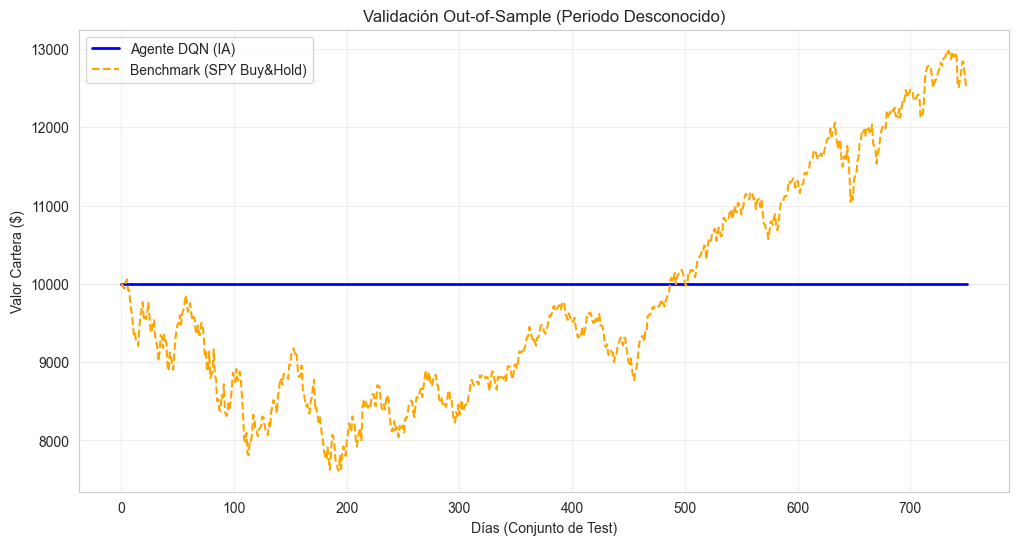

Retorno IA (Test): 0.00%
Retorno SPY (Test): 25.13%


In [6]:
# ==========================================
# FASE 5: VALIDACIÓN RIGUROSA (TRAIN/TEST SPLIT)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. DIVISIÓN DE DATOS (80% Train / 20% Test)
# -------------------------------------------
print("--- 1. Dividiendo datos ---")
split_ratio = 0.8
split_index = int(len(features) * split_ratio)

# Datos que el agente "verá" para aprender (2010 - 2022 aprox)
train_features = features.iloc[:split_index]
train_prices = prices.iloc[:split_index]

# Datos "ocultos" para el examen final (2022 - 2025)
test_features = features.iloc[split_index:]
test_prices = prices.iloc[split_index:]

print(f"Total Días: {len(features)}")
print(f"Entrenamiento: {len(train_features)} días")
print(f"Test (Examen): {len(test_features)} días")

# 2. RE-ENTRENAMIENTO (Desde Cero)
# --------------------------------
# Creamos un agente nuevo que solo conozca los datos de Train
print("\n--- 2. Entrenando Agente en conjunto restringido ---")

train_env = PortfolioEnv(train_prices, train_features, window_size=10)
# Usamos los hiperparámetros ajustados (LR bajo y Decay lento)
agent = DQNAgent(train_env.input_dims, train_env.action_space.n, lr=1e-4, epsilon_decay=0.9995)

# IMPORTANTE: Ponemos suficientes episodios para que aprenda bien antes del examen
train_episodes = 50 # (Aumentar a 300 para el resultado final definitivo)

for e in range(train_episodes):
    state, _ = train_env.reset()
    done = False
    total_reward = 0
    
    while not done:
        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = train_env.step(action)
        done = terminated or truncated
        
        agent.remember(state, action, reward, next_state, done)
        agent.replay() # Aprender
        
        state = next_state
        total_reward += reward
        
    # Actualizar red objetivo cada 10 episodios
    if e % 10 == 0:
        agent.update_target_network()
        print(f"Train Episode {e}/{train_episodes} - Reward: {total_reward:.2f} - Epsilon: {agent.epsilon:.2f}")

# 3. EVALUACIÓN (TEST)
# --------------------
print("\n--- 3. Iniciando Prueba en Datos Desconocidos ---")

# Creamos el entorno con los datos de TEST (2022-2025)
test_env = PortfolioEnv(test_prices, test_features, window_size=10)

# Perfil de usuario para la prueba (Ej. Riesgo Moderado)
test_profile = {'risk_aversion': 0.5, 'time_horizon': 0.5}
state, _ = test_env.reset(options=test_profile)

# CONGELAMOS EL AGENTE:
# 1. Epsilon = 0 (Sin movimientos aleatorios, solo inteligencia)
# 2. Sin replay() (No aprende durante el examen, solo ejecuta)
agent.epsilon = 0.0
done = False

portfolio_values = [test_env.initial_balance]

while not done:
    action = agent.act(state) # Decide basándose solo en lo aprendido en Train
    next_state, reward, terminated, truncated, _ = test_env.step(action)
    done = terminated or truncated
    
    state = next_state
    portfolio_values.append(test_env.portfolio_value)

print("Prueba finalizada.")

# 4. RESULTADOS Y GRÁFICA
# -----------------------
# Calculamos el Benchmark (SPY) solo para el periodo de Test
spy_test = test_prices['SPY'].values
spy_benchmark = (spy_test / spy_test[0]) * test_env.initial_balance

# Gráfica
plt.figure(figsize=(12, 6))
plt.plot(portfolio_values, label='Agente DQN (IA)', color='blue', linewidth=2)
plt.plot(spy_benchmark, label='Benchmark (SPY Buy&Hold)', color='orange', linestyle='--')
plt.title("Validación Out-of-Sample (Periodo Desconocido)")
plt.xlabel("Días (Conjunto de Test)")
plt.ylabel("Valor Cartera ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Métricas Finales
retorno_ia = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0]
retorno_spy = (spy_benchmark[-1] - spy_benchmark[0]) / spy_benchmark[0]

print(f"Retorno IA (Test): {retorno_ia*100:.2f}%")
print(f"Retorno SPY (Test): {retorno_spy*100:.2f}%")
